# Looped Transformer

## 理论

Looped Transformer 所有层共享相同的权重 $\theta$，每层的输入是前一层输出与初始输入的和：

$$
\begin{aligned}
h_0 &= \text{input} \\
h_l &= \text{TransformerBlock}(h_{l-1} + h_0| \theta) \quad \text{for } l=1,2,...,L
\end{aligned}
$$

### 截断损失函数

$$\text{Loss}=\min_{\theta} \mathbb{E}_P \left[ \frac{1}{b - b_0} \sum_{t = b_0}^{b} \frac{1}{k + 1} \sum_{i = 0}^{k} (Y_t(P^i | \theta) - f(x_{i+1}))^2 \right]$$
其中
- $\min_{\theta}$：这是我们在寻找一组最优的物理定律（模型参数 $\theta$）。
- $\mathbb{E}_P$：对所有生成的 Prompt 分布求期望。在统计物理中，这相当于求“系综平均”，即我们在无数种不同的初始条件（数据集）下测试这个定律是否普适。  
- $\frac{1}{b-b_0} \sum_{t=b_0}^{b}$：这是时间平均。$b$ 是总迭代次数，$T$ 是窗口大小，$b_0 = \max(b-T, 0)$。我们只关心系统演化到“稳态”附近的这段时间内(也就是$b_0$ 到 $b$ 的表现)，前面瞬态的误差我们不计较。  
- $\frac{1}{k+1} \sum_{i=0}^{k}$：这是空间/序列平均。也就是在给定不同长度的上下文 $P^i$ 时，模型预测下一个点的值与真实函数 $f(x_{i+1})$ 之间的均方误差。  
- $Y_t(P^i|\theta)$：在时间 $t$、给定历史信息 $P^i$ 和系统参数 $\theta$ 时，系统当前的状态输出。 

### 下游任务

- 数据生成方式：这篇论文解决的是纯粹的数学数据拟合问题。数据集是在训练循环中即时生成的浮点数向量。  
- 以最基础的 **线性回归（Linear Regression）** 为例：
  - 维度设定：问题维度 $d=20$，上下文样本数 $k=40$。  
  - 生成逻辑：每次迭代前，随机采样一个真实的参数 $w \sim \mathcal{N}(0, I_d)$。  
  - 采样输入：生成 $k+1$ 个输入样本（包含测试样本） $x_i \sim \mathcal{N}(0, I_d)$。  
  - 计算标签：$y_i = w^T x_i$。  
  - 拼接成 Prompt：最终喂给模型的序列 $P$ 是一个交替的序列 $(x_1, y_1, x_2, y_2, \dots, x_k, y_k, x_{test}, y_{dummy})$。
- 线性回归可以进一步改成非线性回归（比如 ReLU与Linear 叠加），或者更复杂的物理系统。

#### 把 Prompt 映射到高维 Embedding 空间

**双通道映射与“拉链式”交织**

由于 `x` 和 `y` 代表不同的物理量（一个是空间坐标/特征，一个是目标观测值），我们需要赋予它们独立的投影空间：

1.	定义两个独立的线性层：
```python
read_in_x = nn.Linear(20, 256)
read_in_y = nn.Linear(1, 256)
```
2.	把前`k`个 `x_i` 丢给 `read_in_x`，变成张量 `X_emb`，形状为 `[batch, k, 256]`。
3.	把前`k`个 `y_i` 丢给 `read_in_y`，变成张量 `Y_emb`，形状为 `[batch, k, 256]`。
4.	像拉拉链一样，在`seq_len`维度上把`X_emb`、`Y_emb`交织（Interleave）起来，拼接成最终长度为 `2k` 的提示向量 `P`。

在工程实现中，我们在 $x_{test}$ 后填充了一个 $y_{dummy}$（如 0），使实际拼接长度变为 `2k+2`（偶数）。因此，真正对 $x_{test}$ 的预测结果位于输出序列的倒数第二个位置，即索引 `[-2]` 处。

## 代码

In [354]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time

### 绝对位置编码(APE, Absolute Position Encoding)

In [355]:
class APE(nn.Module):
    def __init__(self, d_model, max_seq_len=4096, b=10000):
        super().__init__()
        theta_i = 1 / (b ** (torch.arange(0, d_model, 2).float() / d_model)) # [d_model/2]
        m = torch.arange(max_seq_len).float() # [max_seq_len]
        m_theta_i = torch.outer(m, theta_i) # [max_seq_len, d_model/2]
        # APE 核心：直接生成一个完整的 pe 矩阵，偶数维度放 sin，奇数维度放 cos
        stacked=torch.stack((torch.sin(m_theta_i), torch.cos(m_theta_i)), dim=-1) # [max_seq_len, d_model/2, 2]
        pe=stacked.flatten(1,2) # [max_seq_len, d_model]
        self.register_buffer('pe', pe.unsqueeze(0)) # shape: [1, max_seq_len, d_model]

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        return x + self.pe[:, :x.shape[1], :]

#### Learned APE

In [356]:
class LearnedAPE(nn.Module):
    def __init__(self, d_model, max_seq_len=4096):
        super().__init__()
        self.pe = nn.Embedding(max_seq_len, d_model) 

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        seq_len = x.shape[1]
        positions = torch.arange(seq_len, device=x.device)
        return x + self.pe(positions).unsqueeze(0)

#### ALiBi (Attention with Linear Biases)

ALiBi 通过更改内积的方式引入线性位置偏置，从而实现了位置编码的功能。
$$ \text{Score}(q_i, k_j) = q_i \cdot k_j - m \cdot (i-j) \quad (i \ge j)$$
其中$m$是一个与头数($H$)相关的斜率参数，硬编码为
$$ m_h = 2^{-\frac{8h}{H}} \quad h=0,1,...,H-1$$

In [357]:
class ALiBi(nn.Module):
    def __init__(self, num_heads, max_seq_len=4096):
        super().__init__()
        dist = torch.arange(max_seq_len) # [max_seq_len]
        dist_matrix = torch.abs(dist.view(-1, 1) - dist.view(1, -1))  # [max_seq_len, max_seq_len]
        bias = -(2**-(8*torch.arange(1,num_heads+1) / num_heads)).view(-1, 1, 1) * dist_matrix.unsqueeze(0)  # [num_heads, max_seq_len, max_seq_len]
        # 因果掩码
        tril = torch.tril(torch.ones(max_seq_len, max_seq_len)).bool() # torch.tril (triangular lower)提取下三角元素，并把上三角元素置0
        mask = torch.zeros(max_seq_len, max_seq_len).masked_fill(~tril, float('-inf')) # 下三角元素置0，上三角元素置-inf
        self.register_buffer('fused_mask', bias + mask) # [num_heads, max_seq_len, max_seq_len]
    
    def forward(self, seq_len):
        # score shape: [batch_size, num_heads, seq_len, seq_len]
        return self.fused_mask[:, :seq_len, :seq_len]

#### 原来的 RoPE (Rotary Position Encoding)

In [358]:
class RoPE(nn.Module):
    def __init__(self, d_k, max_seq_len = 4096, b=10000):
        super().__init__()
        theta_i = 1/(b**(torch.arange(0,d_k,2).float()/d_k))  # \theta_i = b^{-\frac{2i}{d}}, \quad i \in \{0,1,\dots,\frac{d}{2}-1\}
        m = torch.arange(max_seq_len).float()  # m = [0,1,...,seq_len-1]
        m_theta_i = torch.outer(m, theta_i)  # [seq_len, d_k/2]
        cos = torch.cos(torch.cat((m_theta_i, m_theta_i), dim=-1))  # [seq_len, d_k]
        sin = torch.sin(torch.cat((m_theta_i, m_theta_i), dim=-1))  # [seq_len, d_k]
        self.register_buffer('cos', cos[None, None, :, :])  # 好处：cos和sin不需要更新参数，注册为buffer后会自动放到正确的设备上
        self.register_buffer('sin', sin[None, None, :, :])  # 扩充维度以适应后续计算

    def forward(self, x): # 适用于Q、K (V不需要位置编码!)
        # x: [batch_size, num_heads, seq_len, d_k]
        seq_len = x.shape[2]
        d_2 = x.shape[-1] // 2
        cos = self.cos[:, :, :seq_len, :]  # [1, 1, seq_len, d_k]
        sin = self.sin[:, :, :seq_len, :]
        x_first_half = x[..., :d_2]
        x_second_half = x[..., d_2:]
        x_flip = torch.cat((-x_second_half, x_first_half), dim=-1)  
        x_out = x * cos + x_flip * sin  # 旋转位置编码
        return x_out

#### 自创：Multi-Scale Untied Positional Encoding (MS-UPE)

In [359]:
class MS_UPE(nn.Module):
    def __init__(self,num_heads, d_k, max_seq_len = 4096, b_0=10000, head_ratio=2):
        super().__init__()
        b=(b_0*(head_ratio**(torch.arange(0, num_heads)))).float() # [num_heads]
        # \theta_i = b^{-\frac{2i}{d}}, \quad i \in \{0,1,\dots,\frac{d}{2}-1\} 
        theta_i = 1/(b.unsqueeze(1)**(torch.arange(0,d_k,2).float()/d_k).unsqueeze(0))  # [num_heads, d_k/2]
        m = torch.arange(max_seq_len).float()  # m = [0,1,...,seq_len-1]
        m_theta_i = torch.einsum('m,hk->hmk', m, theta_i)  # [num_heads, seq_len, d_k/2]
        pe = torch.cat((torch.cos(m_theta_i), torch.sin(m_theta_i)), dim=-1)  # [num_heads, seq_len, d_k] 
        self.register_buffer('pe', pe[None, :, :, :])  # 好处：pe不需要更新参数，注册为buffer后会自动放到正确的设备上

    def forward(self, x): # 适用于Q、K (V不需要位置编码!)
        # x: [batch_size, num_heads, seq_len, d_k]
        seq_len = x.shape[2]
        pe = self.pe[:, :, :seq_len, :]  # [1, num_heads, seq_len, d_k] 
        x_out = x + pe
        return x_out

### 去掉 RoPE 的 Multi-Head Attention

注：`APE` 应该加在 `ToyModel` 上而不是 `TransformerBlock` 上，因为我们只需要最开头输入处编码位置，而不是叠加 `num_blocks` 次。

In [360]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, d_model, max_seq_len=4096, pe_type='learned_ape', b_rope_or_upe=10000, head_ratio_upe=2):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        # 维度属性
        self.num_heads = num_heads
        self.d_model = d_model
        self.d_k = d_model // num_heads
        # 权重矩阵
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False) 
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        # 位置编码模块
        self.pe_type = [pe_type] if isinstance(pe_type, str) else pe_type
        self.qk_pe_modules = nn.ModuleList()  
        self.sc_pe_modules = nn.ModuleList()
        for pe in self.pe_type:
            if pe == 'rope':
                pe_module = RoPE(self.d_k, max_seq_len, b=b_rope_or_upe)
                self.qk_pe_modules.append(pe_module)  # RoPE应用于Q和K
            elif pe == 'ms_upe':
                pe_module = MS_UPE(num_heads, self.d_k, max_seq_len, b_0=b_rope_or_upe, head_ratio=head_ratio_upe)
                self.qk_pe_modules.append(pe_module)  # MS-UPE应用于Q和K
            elif pe == 'alibi':
                pe_module = ALiBi(num_heads, max_seq_len)
                self.sc_pe_modules.append(pe_module)  # ALiBi应用于score矩阵
            elif pe in ['ape', 'learned_ape']:
                pass  # APE和Learned APE在输入时直接加到x上，不需要单独模块
        # 因果掩码
        tril = torch.tril(torch.ones(max_seq_len, max_seq_len)).bool() # torch.tril (triangular lower)提取下三角元素，并把上三角元素置0
        mask = torch.zeros(max_seq_len, max_seq_len).masked_fill(~tril, float('-inf')) # 下三角元素置0，上三角元素置-inf
        self.register_buffer('mask', mask[None, None, :, :])  # [1, 1, seq_len, seq_len]

    def forward(self, x): # x: [batch_size, seq_len, d_model]
        # 线性投影与分头
        batch_size, seq_len, _ = x.shape
        Q = self.W_Q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)  # [batch_size, num_heads, seq_len, d_k]
        K = self.W_K(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)  # 交换(1, 2)是因为之后softmax时要进行矩阵乘法(只乘后两维)
        V = self.W_V(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)  # 在seq_len维度上分配注意力
        # 根据选择的PE类型对Q和K进行位置编码
        if not self.training:
            # 缩放点积注意力与因果掩码 Causal Masking
            ## Query-Key 点积计算注意力得分
            scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)  # [batch_size, num_heads, seq_len, seq_len]
            ## 因果掩码和 softmax 计算注意力权重
            attention = F.softmax(scores + self.mask[..., :seq_len, :seq_len], dim=-1)  # [batch_size, num_heads, seq_len, seq_len]
            self.captured_attention = attention  # **新增**：捕获注意力矩阵，用hook记录下来，方便后续分析
            ## 乘以 Value 完成加权求和
            out = torch.matmul(attention, V)  # [batch_size, num_heads, seq_len, d_k]
        else:
            for pe_module in self.qk_pe_modules:
                Q = pe_module(Q)
                K = pe_module(K)
            if self.sc_pe_modules:
                fused_mask = self.sc_pe_modules[0](seq_len)  # [num_heads, seq_len, seq_len]
                out = F.scaled_dot_product_attention(Q, K, V, attn_mask=fused_mask, is_causal=False)  # [batch_size, num_heads, seq_len, d_k]
            else:
                out = F.scaled_dot_product_attention(Q, K, V, is_causal=True)  # [batch_size, num_heads, seq_len, d_k]
        # 多头拼接并乘以输出矩阵(必须先内存连续化(contiguous)再view，否则会报错)
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, -1)  # [batch_size, seq_len, d_model]
        H = self.W_O(out)  # [batch_size, seq_len, d_model]
        return H

### SwiGLU 和 单个 Transformer Block 架构不变

In [361]:
class SwiGLU(nn.Module):
    def __init__(self,d_model,d_hidden):
        super().__init__()
        self.W = nn.Linear(d_model,d_hidden,bias=False)
        self.V = nn.Linear(d_model,d_hidden,bias=False)
        self.W2 = nn.Linear(d_hidden,d_model,bias=False)
    def forward(self,x):
        x1 = F.silu(self.W(x))
        x2 = self.V(x)
        x_out = self.W2(x1 * x2)
        return x_out

In [362]:
class TransformerBlock(nn.Module):
    def __init__(self, num_heads, d_model, max_seq_len=4096, multiplier=4, norm_type='layernorm', ffn_type='gelu', pe_type='learned_ape', b_rope_or_upe=10000, head_ratio_upe=2):
        super().__init__()
        if norm_type == 'rmsnorm':
            self.norm1 = nn.RMSNorm(d_model)  # 第一次归一化
            self.norm2 = nn.RMSNorm(d_model)  # 第二次归一化
        elif norm_type == 'layernorm':
            self.norm1 = nn.LayerNorm(d_model)  # 第一次归一化
            self.norm2 = nn.LayerNorm(d_model)  # 第二次归一化
        self.attention = MultiHeadAttention(num_heads, d_model, max_seq_len=max_seq_len, pe_type=pe_type, b_rope_or_upe=b_rope_or_upe, head_ratio_upe=head_ratio_upe)
        if ffn_type == 'swiglu':
            self.ffn = SwiGLU(d_model, d_model * multiplier)
        elif ffn_type == 'gelu':
            self.ffn = nn.Sequential(
                nn.Linear(d_model, d_model * multiplier),
                nn.GELU(),
                nn.Linear(d_model * multiplier, d_model)
            )
    
    def forward(self, x):
        # 第一次归一化 Pre-Norm
        x_norm1 = self.norm1(x)
        # 全局信息交互 Multi-Head Attention (MHA)
        h = self.attention(x_norm1)
        # 第一次残差连接
        x1 = x + h
        # 第二次归一化
        x_norm2 = self.norm2(x1)
        # 前馈网络 Feed-Forward Network (FFN) 
        x_out = self.ffn(x_norm2)
        # 第二次残差连接
        x2 = x1 + x_out
        return x2

### 保留 Attention Probe

In [363]:
class AttentionProbe:
    def __init__(self):
        self.captured_data = []
    def __call__(self, module, input, output):
        if getattr(module, 'captured_attention', None) is not None:
            attention = module.captured_attention.detach().cpu().numpy() 
            self.captured_data.append(attention)
        else:
            self.captured_data.append(None)  # 如果没有捕获到注意力矩阵，记录一个None占位符
    def reset(self):
        self.captured_data = [] 

### Toy Model: Looped Transformer

In [364]:
class ToyModel(nn.Module):
    def __init__(self, num_blocks, num_heads, d_model, max_seq_len=4096, 
                 norm_type='layernorm', ffn_type='gelu', pe_type='learned_ape', b_rope_or_upe=10000, head_ratio_upe=2,
                 loop=True, residual_gate=(1,1), residual_gate_type='fixed', residual_random=(1,0.1)):
        super().__init__()
        self.loop = loop
        if loop:
            self.transformer_block = TransformerBlock(num_heads, d_model, max_seq_len=max_seq_len, norm_type=norm_type, ffn_type=ffn_type, pe_type=pe_type, b_rope_or_upe=b_rope_or_upe, head_ratio_upe=head_ratio_upe) # 这里保证了各层权重始终相同
            self.probe = AttentionProbe()
            self.transformer_block.attention.register_forward_hook(self.probe)
            self.captured_attention = None
        else:
            self.transformer_block = nn.ModuleList([
                TransformerBlock(num_heads, d_model, max_seq_len=max_seq_len, norm_type=norm_type, ffn_type=ffn_type, pe_type=pe_type, b_rope_or_upe=b_rope_or_upe, head_ratio_upe=head_ratio_upe) 
                for _ in range(num_blocks)
            ])
            self.probe = [AttentionProbe() for _ in range(num_blocks)]
            for block, probe in zip(self.transformer_block, self.probe):
                block.attention.register_forward_hook(probe)

        residual_random = torch.tensor(residual_random, dtype=torch.float32)
        if residual_gate == 'random':
            residual_gate_tensor = torch.randn(2)*residual_random[1]+residual_random[0] # 随机初始化门控参数，初始正态分布
        else:
            residual_gate_tensor = torch.tensor(residual_gate, dtype=torch.float32)  # 将输入的元组转换为张量，方便后续计算
        if residual_gate_type == 'fixed':
            self.register_buffer('residual_gate', residual_gate_tensor)  # 固定的门控参数，注册为buffer使其成为模型状态的一部分，但不参与梯度更新
        elif residual_gate_type == 'learnable_scalar':
            self.residual_gate = nn.Parameter(torch.ones(2)*residual_gate_tensor)  # 可学习的标量门控参数，初始值为1.0
        elif residual_gate_type == 'learnable_vector':
            if residual_gate == 'random':
                self.residual_gate = nn.Parameter(torch.randn(d_model, 2)*residual_random[1]+residual_random[0]) # 可学习的向量门控参数，初始值为随机向量
            else:
                self.residual_gate = nn.Parameter(torch.ones(d_model, 2)*residual_gate_tensor)  # 可学习的向量门控参数，初始值为全1向量
            
        pe_type = self.transformer_block.attention.pe_type
        self.ape = nn.ModuleList()
        for pe in pe_type:
            if pe == 'ape':
                self.ape.append(APE(d_model, max_seq_len=max_seq_len))
            elif pe == 'learned_ape':
                self.ape.append(LearnedAPE(d_model, max_seq_len=max_seq_len))
            elif pe in ['rope', 'ms_upe']:
                pass # RoPE和MS_UPE在MultiHeadAttention内部处理位置编码，不需要单独的模块在这里处理

        self.num_blocks = num_blocks
        self.num_heads = num_heads
        self.d_model = d_model
        self.max_seq_len = max_seq_len
        self.pe_type = pe_type

    def forward(self, x_0, num_eff=15, current_blocks=None): 
        # num_eff 是需要加入误差计算的有效层数，也即理论公式中的 T
        # x 的形状为 [batch_size, seq_len, d_model]
        a=self.residual_gate[...,0]
        b=self.residual_gate[...,1]
        for ape_module in self.ape:
            x_0 = ape_module(x_0) # 绝对位置编码只加在最开始输入处
        x = x_0
        if current_blocks is None:
            current_blocks = self.num_blocks
        b_0 = max(0, current_blocks - num_eff) # 计算需要加入误差计算的有效层数对应的起始层索引
        outputs = []
        if self.loop:
            self.probe.reset() # 每次前向传播前重置捕获的数据，避免混淆不同次前向传播的注意力矩阵
            for i in range(current_blocks):
                if i == b_0:
                    x= x.detach() # 释放前面的计算图
                    x.requires_grad_(True)
                x = self.transformer_block(a*x+b*x_0)
                if i >= b_0: 
                    outputs.append(x) 
            self.captured_attention = list(self.probe.captured_data) # 显式copy一份数据，避免后续被修改
        else:
            for probe in self.probe:
                probe.reset()
            for i, block in enumerate(self.transformer_block):
                if i == b_0:
                    x= x.detach() # 释放前面的计算图
                    x.requires_grad_(True)
                x = block(a*x+b*x_0) # x: [batch_size, seq_len, d_model]
                if i >= b_0: 
                    outputs.append(x)
            self.captured_attention = [probe.captured_data for probe in self.probe]
        outputs = torch.stack(outputs, dim=1) # [batch_size, num_eff, seq_len, d_model]
        return outputs

### Downstream Task: Linear Regression

#### 转换头

In [365]:
class RegressionHead(nn.Module):
    def __init__(self, d_model, d_x, d_y=1, bias=False, init_scale=None):
        super().__init__()
        self.read_in_x = nn.Linear(d_x, d_model, bias=bias)
        self.read_in_y = nn.Linear(d_y, d_model, bias=bias)
        if init_scale is not None:
            nn.init.normal_(self.read_in_x.weight, mean=0.0, std=init_scale)
            nn.init.normal_(self.read_in_y.weight, mean=0.0, std=init_scale)
    def forward(self, x_data, y_data):
        # k相当于seq_len的一半，因为x和y交织在一起，所以总的seq_len是2k
        # x_data: [batch_size, k, d_x]
        # y_data: [batch_size, k, d_y]
        x_emb = self.read_in_x(x_data)  # [batch_size, k, d_model]
        y_emb = self.read_in_y(y_data)  # [batch_size, k, d_model]
        # 交织成 (x_1, y_1, x_2, y_2, ..., x_k, y_k)
        stacked = torch.stack((x_emb, y_emb), dim=2)  # [batch_size, k, 2, d_model]
        Prompt = stacked.flatten(1,2)  # [batch_size, 2k, d_model]
        return Prompt

#### 损失函数

In [366]:
class PredictionLoss(nn.Module):
    def __init__(self, d_model, d_y=1, loss_type='mse'):
        super().__init__()
        self.read_out = nn.Linear(d_model, d_y)
        if loss_type == 'mse':
            self.loss_fn = nn.MSELoss()
        elif loss_type == 'l1':
            self.loss_fn = nn.L1Loss()

    def forward(self, outputs, y_true, is_eval=False, sink_padding=None): 
        # outputs:[batch_size, num_eff, seq_len, d_model]
        # y_true: [batch_size, seq_len/2, 1]
        if is_eval:
            y_outputs = outputs[:, -1, -2, :] # 只取最后一层的最后一个位置的输出作为预测值
            y_pred_final = self.read_out(y_outputs) # [batch_size, d_y]
            return y_pred_final
        y_outputs = outputs[:, :, 0::2, :] # [batch_size, num_eff, seq_len/2, d_model]
        y_preds = self.read_out(y_outputs) # [batch_size, num_eff, seq_len/2, d_y]
        if sink_padding is not None:
            y_preds = y_preds[:, :, sink_padding:, :]
            y_true = y_true[:, sink_padding:, :]
        loss = self.loss_fn(y_preds, y_true.unsqueeze(1).expand_as(y_preds)) # [batch_size, num_eff, seq_len/2, d_y]
        return loss

#### 拼装

In [367]:
class RegressionSolver(nn.Module):
    def __init__(self, num_blocks, num_heads, d_model, d_x, d_y, max_seq_len, 
                 norm_type='layernorm', ffn_type='gelu', pe_type='learned_ape', b_rope_or_upe=10000, head_ratio_upe=2,
                  loop=True, loss_type='mse', 
                  residual_gate=(1,1), residual_gate_type='fixed', residual_random=(1,0.1),
                  bias=False, init_scale=None):
        super().__init__()
        self.toy_model = ToyModel(num_blocks, num_heads, d_model, max_seq_len, norm_type=norm_type, ffn_type=ffn_type, pe_type=pe_type, loop=loop, b_rope_or_upe=b_rope_or_upe, head_ratio_upe=head_ratio_upe, residual_gate=residual_gate, residual_gate_type=residual_gate_type, residual_random=residual_random)
        self.head = RegressionHead(d_model, d_x, d_y, bias=bias, init_scale=init_scale)
        self.loss_fn = PredictionLoss(d_model, d_y, loss_type=loss_type)
        
    def forward(self, x_data, y_data, num_eff, current_blocks=None, is_eval=False, sink_padding=None):
        Prompt = self.head(x_data, y_data) # [batch_size, seq_len, d_model]
        outputs = self.toy_model(Prompt, num_eff, current_blocks=current_blocks) # [batch_size, num_eff, seq_len, d_model]
        output = self.loss_fn(outputs, y_data, is_eval=is_eval, sink_padding=sink_padding)
        return output

### 数据生成与加载

#### 数据生成

##### 线性回归数据

In [368]:
def linear_data_generator(batch_size, seq_len, d_x, d_y, device='cpu'):
    w = torch.randn(batch_size, d_x, d_y, device=device)  # 真实线性函数 w: [batch_size, d_x, d_y]
    x_data = torch.randn(batch_size, seq_len//2, d_x, device=device)  # 输入特征 x: [batch_size, seq_len//2, d_x]
    y_data = x_data @ w  # 计算标签 y = x @ w: [batch_size, seq_len//2, d_y]
    return x_data, y_data

#### 数据加载器

In [369]:
def dataloader(batch_size=64, seq_len=80, d_x=20, d_y=1, device='cpu', data_type='linear', sink_padding=1):
    while True:
        if data_type == 'linear':
            x_data, y_data = linear_data_generator(batch_size, seq_len, d_x, d_y, device=device)
        if sink_padding is not None:
            x_data = F.pad(x_data, (0, 0, sink_padding, 0), value=0)  # 在seq_len维度最前面添加sink_padding个全0向量
            y_data = F.pad(y_data, (0, 0, sink_padding, 0), value=0)
        yield x_data, y_data

### 实验模块

In [370]:
class LoopedTransformerExperiment:
    def __init__(self, num_blocks, num_heads=8, d_model=256, lr=1e-4, max_seq_len=4096, d_x=20, d_y=1, seed=None, experiment_name='Experiment',
                 norm_type='layernorm', ffn_type='gelu', pe_type='learned_ape', b_rope_or_upe=10000, head_ratio_upe=2,
                 optimizer_type='adam', loop=True, loss_type='mse', bias=False, init_scale=None, 
                 residual_gate=(1,1), residual_gate_type='fixed', residual_random=(1,0.1),
                 task='regression', timing=True):
        if timing:
            start_time = time.time()
        # 设备选择：优先使用 MPS（适用于 Apple Silicon），其次是 CUDA（适用于 NVIDIA GPU），最后退回 CPU
        if torch.backends.mps.is_available():
            self.device = torch.device("mps")
        elif torch.cuda.is_available():
            self.device = torch.device("cuda")
        else:
            self.device = torch.device("cpu")
        if seed is not None:
            torch.manual_seed(seed)
        # 模型和优化器
        self.task = task
        if task == 'regression':
            self.model = RegressionSolver(num_blocks, num_heads, d_model, d_x=d_x, d_y=d_y, max_seq_len=max_seq_len, 
                                          norm_type=norm_type, ffn_type=ffn_type, pe_type=pe_type, b_rope_or_upe=b_rope_or_upe, 
                                          head_ratio_upe=head_ratio_upe, loop=loop, loss_type=loss_type, 
                                          bias=bias, init_scale=init_scale, 
                                          residual_gate=residual_gate, residual_gate_type=residual_gate_type, residual_random=residual_random
                                          ).to(self.device)
        if optimizer_type == 'adam':
            self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        elif optimizer_type == 'sgd':
            self.optimizer = torch.optim.SGD(self.model.parameters(), lr=lr)
        self.d_x = d_x
        self.d_y = d_y 
        self.num_blocks = num_blocks
        if experiment_name is not None:
            if timing:
                init_time = time.time() - start_time
                print(f"{experiment_name} initialized in {init_time:.2f} seconds. Using device: {self.device}")
            else:
                print(f"{experiment_name} initialized. Using device: {self.device}")

    def train(self, batch_size=64, seq_len=80, epochs=20, data_type='linear', num_eff=15, sink_padding=None, scheduled_training=True, print_every=None, timing=False):
        # x_data: [batch_size, k, d_x]
        # y_data: [batch_size, k, d_y]
        self.model.train()
        self.data_loader = dataloader(batch_size, seq_len, self.d_x, self.d_y, device=self.device, data_type=data_type, sink_padding=sink_padding)
        self.loss_history = []
        num_eff = min(num_eff, self.num_blocks) # 确保 num_eff 不超过总层数
        if timing:
            start_time = time.time()
        for epoch in range(epochs):
            self.optimizer.zero_grad()
            x_data, y_data = next(self.data_loader) # 从数据加载器中获取一个批次的数据
            if scheduled_training:
                current_blocks = min(num_eff + epoch, self.num_blocks) # 随着训练的进行，逐渐增加参与误差计算的有效层数
            else:
                current_blocks = self.num_blocks
            loss = self.model(x_data, y_data, num_eff=num_eff, current_blocks=current_blocks, is_eval=False, sink_padding=sink_padding) # 前向传播计算损失 [batch_size, num_eff, seq_len/2, d_y]
            loss = loss.mean()  # 对所有维度求平均得到一个标量损失值
            loss.backward()  # 反向传播计算梯度
            self.optimizer.step()  # 更新模型参数
            self.loss_history.append(loss.item())  # 记录损失值
            if print_every is not None and (epoch + 1) % print_every == 0:
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, current_blocks: {current_blocks}")
        if timing:
            end_time = time.time()
            print(f"Training completed in {end_time - start_time:.2f} seconds.")
        self.residual_gate_values = self.model.toy_model.residual_gate.detach().cpu().numpy() if hasattr(self.model.toy_model, 'residual_gate') else None
            
    def evaluate(self, batch_size=64, seq_len=80, data_type='linear', loss_type='mse', sink_padding=1):
        self.model.eval()
        with torch.no_grad():
            # 在评估模式下，直接使用所有层的输出进行预测(因为已经no_grad了，所以不需要防止梯度爆炸了)
            x_eval, y_eval = next(dataloader(batch_size, seq_len+1, self.d_x, self.d_y, device=self.device, data_type=data_type, sink_padding=sink_padding))
            y_pred = self.model(x_eval, y_eval, num_eff=self.num_blocks, current_blocks=self.num_blocks, is_eval=True, sink_padding=sink_padding) # [batch_size, d_y]
            if loss_type == 'mse':
                mse=F.mse_loss(y_pred, y_eval[:, -1, :])
                print(f"MSELoss: {mse:.4f}") # 计算预测值与真实值之间的均方误差
            elif loss_type == 'l1':
                l1=F.l1_loss(y_pred, y_eval[:, -1, :])
                print(f"L1Loss: {l1:.4f}") 
        return y_pred

### 默认配置参数

In [371]:
def default_setup():
    init_parameters = {
    # RoPE/MS-UPE
        'b_rope_or_upe': 10000,            # float: RoPE或UPE的基数
        'head_ratio_upe': 2,               # float: UPE头比例

    # MultiHeadAttention
        'num_heads': 8,                    # int: 注意力头数 H
        'd_model': 256,                    # int: Transformer 的维度 D
        'max_seq_len': 100,                # int: 模型支持的最大序列长度（位置编码相关）
        'pe_type': ['learned_ape'],        # list: 位置编码类型 ('ape', 'learned_ape', 'rope', 'ms_upe', 'alibi')

    # TransformerBlock
        'norm_type': 'layernorm',          # str: transformer_block 中的归一化类型 ('layernorm' 或 'rmsnorm')
        'ffn_type': 'gelu',                # str: transformer_block 中前馈网络激活函数类型 ('gelu' 或 'swiglu')

    # ToyModel
        'num_blocks': 20,                  # int: Transformer 的层数 b
        'loop': True,                      # bool: 是否权重共享
        'residual_gate': (1,1),            # tuple or str: transformer_block 之间传递残差的门控参数初始值,使`x=a*x+b*x_0` ((a,b)或'random')
        'residual_gate_type': 'fixed',     # str: 残差门控类型 ('fixed', 'learnable_scalar', 'learnable_vector')
        'residual_random': (1,0.1),         # tuple (mean, std): 当 residual_gate='random' 时满足高斯分布 N(mean, std)

    # RegressionHead
        'd_x': 20,                         # int: 数据输入的特征维度
        'd_y': 1,                          # int: 数据输出的特征维度
        'bias': False,                     # bool: Regression Head 是否使用偏置
        'init_scale': None,                # float or None: Regression Head 的初始化缩放因子(None表示使用默认初始化)

    # PredictionLoss
        'loss_type': 'mse',                # str: 损失函数类型 ('mse' 或 'l1')

    # LoopedTransformerExperiment
        'lr': 1e-4,                        # float: 学习率
        'seed': 42,                        # int or None: 手动随机种子，确保实验可复现
        'experiment_name': 'Experiment',   # str or None: 实验名称 (None表示不打印设备和实验初始化信息)
        'timing': True,                    # bool: 是否打印初始化时间
        'optimizer_type': 'adam',          # str: 优化器类型 ('adam' 或 'sgd')
        'task': 'regression',              # str: 任务类型 ('regression')
    }

    train_parameters = {
    # MultiHeadAttention
        'batch_size': 64,                  # int: 数据批次大小
        'seq_len': 80,                     # int: 数据序列长度

    # ToyModel
        'num_eff': 15,                     # int: 有效层数，即参与误差计算、参与梯度反向传播的层数 T=b-b_0

    # dataloader
        'sink_padding': None,              # int or None: seq 最前面填充的 sink token 组数 (None表示不使用sink padding)
        
    # LoopedTransformerExperiment
        'epochs': 20,                      # int: 训练轮数
        'data_type': 'linear',             # str: 回归数据类型 ('linear')
        'scheduled_training': True,        # bool: 是否使用计划训练，即随着训练的进行逐渐增加参与的层数 b=epoch+num_eff ，直到达到最大层数num_blocks
        'print_every': 5,                  # int or None: 打印频率/epoch (None表示不打印训练过程中的损失信息)
        'timing': True,                    # bool: 是否打印训练时间
    }
    return init_parameters, train_parameters

## 主程序

### 实验数据观测

#### 绘制 Loss 下降曲线

Experiment initialized in 0.03 seconds. Using device: mps
Epoch 5/20, Loss: 72.5179, current_blocks: 19
Epoch 10/20, Loss: 35.3423, current_blocks: 20
Epoch 15/20, Loss: 26.2775, current_blocks: 20
Epoch 20/20, Loss: 24.8684, current_blocks: 20
Training completed in 7.86 seconds.
Final residual gate values: [1. 1.]


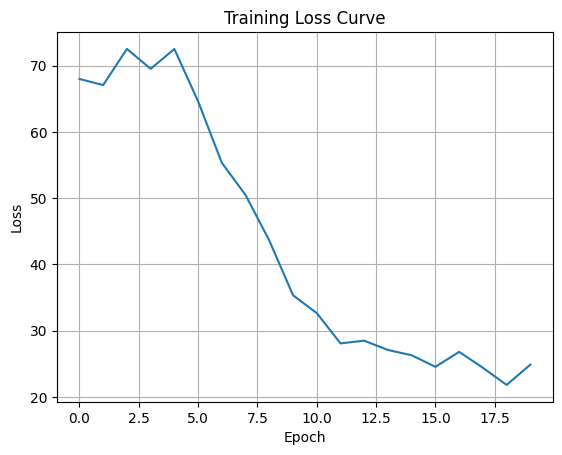

In [ ]:
init_parameters, train_parameters = default_setup()
experiment = LoopedTransformerExperiment(**init_parameters)
experiment.train(**train_parameters)
print(f"Final residual gate values: {experiment.residual_gate_values}")
plt.plot(experiment.loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid()
plt.show()

### 对比实验

#### Scheduled Training vs Non-Scheduled Training 对比实验

Experiment scheduled initialized in 0.03 seconds. Using device: mps
Epoch 5/20, Loss: 72.5179, current_blocks: 19
Epoch 10/20, Loss: 35.3423, current_blocks: 20
Epoch 15/20, Loss: 26.2775, current_blocks: 20
Epoch 20/20, Loss: 24.8684, current_blocks: 20
Training completed in 8.79 seconds.
Experiment non-scheduled initialized in 0.06 seconds. Using device: mps
Epoch 5/20, Loss: 79.9593, current_blocks: 20
Epoch 10/20, Loss: 36.1977, current_blocks: 20
Epoch 15/20, Loss: 26.3801, current_blocks: 20
Epoch 20/20, Loss: 24.8631, current_blocks: 20
Training completed in 6.82 seconds.


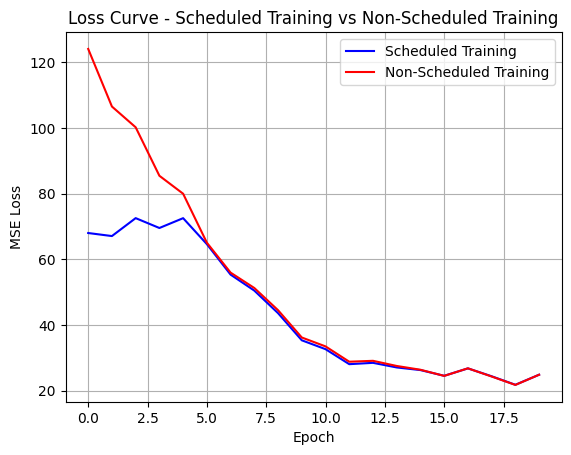

In [ ]:
init_parameters, train_parameters = default_setup()
init_parameters['experiment_name'] = 'Experiment scheduled'
experiment1 = LoopedTransformerExperiment(**init_parameters)
experiment1.train(**train_parameters)

init_parameters['experiment_name'] = 'Experiment non-scheduled'
train_parameters['scheduled_training'] = False
experiment2 = LoopedTransformerExperiment(**init_parameters)
experiment2.train(**train_parameters)

plt.plot(experiment1.loss_history, label='Scheduled Training', color='blue')
plt.plot(experiment2.loss_history, label='Non-Scheduled Training', color='red')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss Curve - Scheduled Training vs Non-Scheduled Training')
plt.grid()
plt.legend()
plt.show()

#### 不同 Positional Embedding 对比实验

##### 初始参数

In [ ]:
init_parameters, train_parameters = default_setup()

##### 各个实验

In [ ]:
init_parameters['experiment_name'] = 'learning_ape_exp'
learning_ape_exp = LoopedTransformerExperiment(**init_parameters)
learning_ape_exp.train(**train_parameters)

learned_ape_exp initialized. Using device: mps
Epoch 5/100, Loss: 41.1805, current_blocks: 19
Epoch 10/100, Loss: 18.3069, current_blocks: 20
Epoch 15/100, Loss: 7.0673, current_blocks: 20
Epoch 20/100, Loss: 5.1770, current_blocks: 20
Epoch 25/100, Loss: 5.9387, current_blocks: 20
Epoch 30/100, Loss: 4.4391, current_blocks: 20
Epoch 35/100, Loss: 3.7256, current_blocks: 20
Epoch 40/100, Loss: 3.1097, current_blocks: 20
Epoch 45/100, Loss: 3.2062, current_blocks: 20
Epoch 50/100, Loss: 2.9484, current_blocks: 20
Epoch 55/100, Loss: 2.6715, current_blocks: 20
Epoch 60/100, Loss: 2.9714, current_blocks: 20
Epoch 65/100, Loss: 2.3141, current_blocks: 20
Epoch 70/100, Loss: 2.6434, current_blocks: 20
Epoch 75/100, Loss: 2.3794, current_blocks: 20
Epoch 80/100, Loss: 2.3924, current_blocks: 20
Epoch 85/100, Loss: 2.8761, current_blocks: 20
Epoch 90/100, Loss: 3.1192, current_blocks: 20
Epoch 95/100, Loss: 3.2056, current_blocks: 20
Epoch 100/100, Loss: 2.6971, current_blocks: 20
Training co

In [87]:
init_parameters['experiment_name'] = 'ape_exp'
init_parameters['pe_type'] = 'ape'
ape_exp = LoopedTransformerExperiment(**init_parameters)
ape_exp.train(**train_parameters)

ape_exp initialized. Using device: mps
Epoch 5/100, Loss: 10.5527, current_blocks: 19
Epoch 10/100, Loss: 9.5900, current_blocks: 20
Epoch 15/100, Loss: 6.6546, current_blocks: 20
Epoch 20/100, Loss: 5.5995, current_blocks: 20
Epoch 25/100, Loss: 4.4722, current_blocks: 20
Epoch 30/100, Loss: 3.7418, current_blocks: 20
Epoch 35/100, Loss: 3.0496, current_blocks: 20
Epoch 40/100, Loss: 2.7531, current_blocks: 20
Epoch 45/100, Loss: 2.7307, current_blocks: 20
Epoch 50/100, Loss: 2.3372, current_blocks: 20
Epoch 55/100, Loss: 2.0070, current_blocks: 20
Epoch 60/100, Loss: 2.4516, current_blocks: 20
Epoch 65/100, Loss: 1.9479, current_blocks: 20
Epoch 70/100, Loss: 2.1836, current_blocks: 20
Epoch 75/100, Loss: 1.9636, current_blocks: 20
Epoch 80/100, Loss: 2.0577, current_blocks: 20
Epoch 85/100, Loss: 2.4641, current_blocks: 20
Epoch 90/100, Loss: 2.7406, current_blocks: 20
Epoch 95/100, Loss: 2.6699, current_blocks: 20
Epoch 100/100, Loss: 2.2478, current_blocks: 20
Training completed i

In [88]:
init_parameters['experiment_name'] = 'alibi_exp'
init_parameters['pe_type'] = 'alibi'
alibi_exp = LoopedTransformerExperiment(**init_parameters)
alibi_exp.train(**train_parameters)

alibi_exp initialized. Using device: mps
Epoch 5/100, Loss: 7.9440, current_blocks: 19
Epoch 10/100, Loss: 5.0251, current_blocks: 20
Epoch 15/100, Loss: 4.0158, current_blocks: 20
Epoch 20/100, Loss: 3.2134, current_blocks: 20
Epoch 25/100, Loss: 3.3868, current_blocks: 20
Epoch 30/100, Loss: 2.5129, current_blocks: 20
Epoch 35/100, Loss: 2.3932, current_blocks: 20
Epoch 40/100, Loss: 2.3417, current_blocks: 20
Epoch 45/100, Loss: 2.4873, current_blocks: 20
Epoch 50/100, Loss: 1.9661, current_blocks: 20
Epoch 55/100, Loss: 1.7287, current_blocks: 20
Epoch 60/100, Loss: 2.0730, current_blocks: 20
Epoch 65/100, Loss: 1.7679, current_blocks: 20
Epoch 70/100, Loss: 2.1053, current_blocks: 20
Epoch 75/100, Loss: 1.9362, current_blocks: 20
Epoch 80/100, Loss: 1.7442, current_blocks: 20
Epoch 85/100, Loss: 2.1672, current_blocks: 20
Epoch 90/100, Loss: 2.5389, current_blocks: 20
Epoch 95/100, Loss: 2.2342, current_blocks: 20
Epoch 100/100, Loss: 2.1209, current_blocks: 20
Training completed 

In [89]:
init_parameters['experiment_name'] = 'rope_exp'
init_parameters['pe_type'] = 'rope'
init_parameters['b_rope_or_upe'] = 10000
rope_exp = LoopedTransformerExperiment(**init_parameters)
rope_exp.train(**train_parameters)

rope_exp initialized. Using device: mps
Epoch 5/100, Loss: 8.5121, current_blocks: 19
Epoch 10/100, Loss: 5.3167, current_blocks: 20
Epoch 15/100, Loss: 3.9336, current_blocks: 20
Epoch 20/100, Loss: 3.2812, current_blocks: 20
Epoch 25/100, Loss: 3.6321, current_blocks: 20
Epoch 30/100, Loss: 2.6115, current_blocks: 20
Epoch 35/100, Loss: 2.4616, current_blocks: 20
Epoch 40/100, Loss: 2.4041, current_blocks: 20
Epoch 45/100, Loss: 2.5846, current_blocks: 20
Epoch 50/100, Loss: 2.0036, current_blocks: 20
Epoch 55/100, Loss: 1.7312, current_blocks: 20
Epoch 60/100, Loss: 2.1332, current_blocks: 20
Epoch 65/100, Loss: 1.7742, current_blocks: 20
Epoch 70/100, Loss: 2.0761, current_blocks: 20
Epoch 75/100, Loss: 1.9971, current_blocks: 20
Epoch 80/100, Loss: 1.7743, current_blocks: 20
Epoch 85/100, Loss: 2.2035, current_blocks: 20
Epoch 90/100, Loss: 2.6322, current_blocks: 20
Epoch 95/100, Loss: 2.3430, current_blocks: 20
Epoch 100/100, Loss: 2.2058, current_blocks: 20
Training completed i

In [90]:
init_parameters['experiment_name'] = 'ms_upe_exp'
init_parameters['pe_type'] = 'ms_upe'
init_parameters['b_rope_or_upe'] = 10000
init_parameters['head_ratio_upe'] = 2
ms_upe_exp = LoopedTransformerExperiment(**init_parameters)
ms_upe_exp.train(**train_parameters)

ms_upe_exp initialized. Using device: mps
Epoch 5/100, Loss: 8.0830, current_blocks: 19
Epoch 10/100, Loss: 5.2086, current_blocks: 20
Epoch 15/100, Loss: 4.1812, current_blocks: 20
Epoch 20/100, Loss: 2.9801, current_blocks: 20
Epoch 25/100, Loss: 3.2729, current_blocks: 20
Epoch 30/100, Loss: 2.6667, current_blocks: 20
Epoch 35/100, Loss: 2.5216, current_blocks: 20
Epoch 40/100, Loss: 2.3067, current_blocks: 20
Epoch 45/100, Loss: 2.4673, current_blocks: 20
Epoch 50/100, Loss: 2.0190, current_blocks: 20
Epoch 55/100, Loss: 1.7739, current_blocks: 20
Epoch 60/100, Loss: 2.1786, current_blocks: 20
Epoch 65/100, Loss: 1.8399, current_blocks: 20
Epoch 70/100, Loss: 2.0640, current_blocks: 20
Epoch 75/100, Loss: 2.0052, current_blocks: 20
Epoch 80/100, Loss: 1.8559, current_blocks: 20
Epoch 85/100, Loss: 2.2586, current_blocks: 20
Epoch 90/100, Loss: 2.6707, current_blocks: 20
Epoch 95/100, Loss: 2.3728, current_blocks: 20
Epoch 100/100, Loss: 2.3211, current_blocks: 20
Training completed

In [91]:
init_parameters['experiment_name'] = 'ms_upe&learned_ape_exp'
init_parameters['pe_type'] = ['ms_upe', 'learned_ape']
init_parameters['b_rope_or_upe'] = 10000
init_parameters['head_ratio_upe'] = 2
ms_upe_learned_ape_exp = LoopedTransformerExperiment(**init_parameters)
ms_upe_learned_ape_exp.train(**train_parameters)

ms_upe&learned_ape_exp initialized. Using device: mps
Epoch 5/100, Loss: 41.0124, current_blocks: 19
Epoch 10/100, Loss: 17.5966, current_blocks: 20
Epoch 15/100, Loss: 6.7853, current_blocks: 20
Epoch 20/100, Loss: 5.4592, current_blocks: 20
Epoch 25/100, Loss: 6.0685, current_blocks: 20
Epoch 30/100, Loss: 4.3091, current_blocks: 20
Epoch 35/100, Loss: 3.6125, current_blocks: 20
Epoch 40/100, Loss: 3.1510, current_blocks: 20
Epoch 45/100, Loss: 3.2357, current_blocks: 20
Epoch 50/100, Loss: 2.9586, current_blocks: 20
Epoch 55/100, Loss: 2.6367, current_blocks: 20
Epoch 60/100, Loss: 2.9363, current_blocks: 20
Epoch 65/100, Loss: 2.3051, current_blocks: 20
Epoch 70/100, Loss: 2.6297, current_blocks: 20
Epoch 75/100, Loss: 2.3529, current_blocks: 20
Epoch 80/100, Loss: 2.3792, current_blocks: 20
Epoch 85/100, Loss: 2.8603, current_blocks: 20
Epoch 90/100, Loss: 3.1174, current_blocks: 20
Epoch 95/100, Loss: 3.1854, current_blocks: 20
Epoch 100/100, Loss: 2.6862, current_blocks: 20
Trai

##### 画图

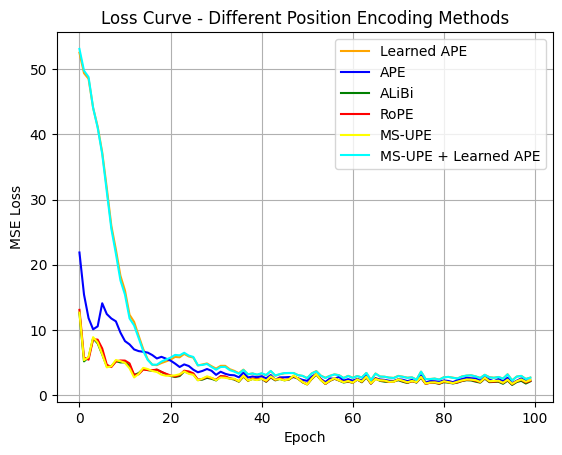

In [92]:
plt.plot(learning_ape_exp.loss_history, label='Learned APE', color='orange')
plt.plot(ape_exp.loss_history, label='APE', color='blue')
plt.plot(alibi_exp.loss_history, label='ALiBi', color='green')
plt.plot(rope_exp.loss_history, label='RoPE', color='red')
plt.plot(ms_upe_exp.loss_history, label='MS-UPE', color='yellow')
plt.plot(ms_upe_learned_ape_exp.loss_history, label='MS-UPE + Learned APE', color='cyan')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss Curve - Different Position Encoding Methods')
plt.grid()
plt.legend()
plt.show()

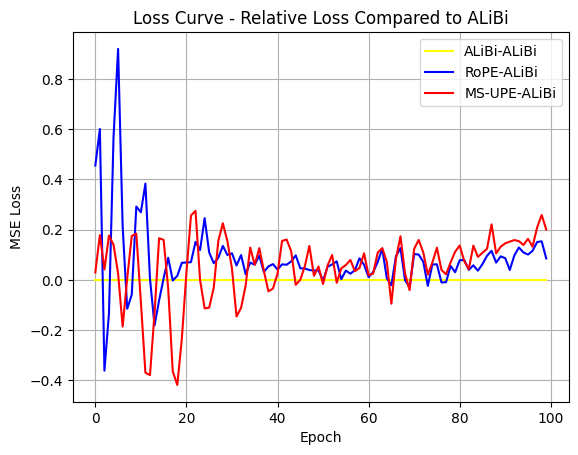

In [93]:
from operator import sub
plt.plot(list(map(sub, alibi_exp.loss_history, alibi_exp.loss_history)), label='ALiBi-ALiBi', color='yellow')
plt.plot(list(map(sub, rope_exp.loss_history, alibi_exp.loss_history)), label='RoPE-ALiBi', color='blue')
plt.plot(list(map(sub, ms_upe_exp.loss_history, alibi_exp.loss_history)), label='MS-UPE-ALiBi', color='red')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss Curve - Relative Loss Compared to ALiBi')
plt.grid()
plt.legend()
plt.show()

#### sink padding 的有无对比实验

##### 初始参数

In [ ]:
init_parameters, train_parameters = default_setup()

##### 各个实验

In [ ]:
init_parameters['experiment_name'] = 'exp_without_sink_padding'
experiment = LoopedTransformerExperiment(**init_parameters)
experiment.train(**train_parameters)

exp_without_sink_padding initialized. Using device: mps
Epoch 10/100, Loss: 28.5238, current_blocks: 20
Epoch 20/100, Loss: 8.0300, current_blocks: 20
Epoch 30/100, Loss: 7.5267, current_blocks: 20
Epoch 40/100, Loss: 5.7270, current_blocks: 20
Epoch 50/100, Loss: 6.4822, current_blocks: 20
Epoch 60/100, Loss: 5.4732, current_blocks: 20
Epoch 70/100, Loss: 5.6123, current_blocks: 20
Epoch 80/100, Loss: 5.7751, current_blocks: 20
Epoch 90/100, Loss: 5.3166, current_blocks: 20
Epoch 100/100, Loss: 5.1050, current_blocks: 20
Training completed in 35.23 seconds.
exp_with_sink_padding_1 initialized. Using device: mps
Epoch 10/100, Loss: 29.0763, current_blocks: 20
Epoch 20/100, Loss: 8.1317, current_blocks: 20
Epoch 30/100, Loss: 7.6203, current_blocks: 20
Epoch 40/100, Loss: 5.7289, current_blocks: 20
Epoch 50/100, Loss: 6.5180, current_blocks: 20
Epoch 60/100, Loss: 5.4713, current_blocks: 20
Epoch 70/100, Loss: 5.6689, current_blocks: 20
Epoch 80/100, Loss: 5.7402, current_blocks: 20
Epo

In [ ]:
init_parameters['experiment_name'] = 'exp_with_sink_padding_1'
train_parameters['sink_padding'] = 1
experiment_with_sink_padding_1 = LoopedTransformerExperiment(**init_parameters)
experiment_with_sink_padding_1.train(**train_parameters)

In [ ]:
init_parameters['experiment_name'] = 'exp_with_sink_padding_2'
train_parameters['sink_padding'] = 2
experiment_with_sink_padding_2 = LoopedTransformerExperiment(**init_parameters)
experiment_with_sink_padding_2.train(**train_parameters)

In [ ]:
init_parameters['experiment_name'] = 'exp_with_sink_padding_5'
train_parameters['sink_padding'] = 5
experiment_with_sink_padding_5 = LoopedTransformerExperiment(**init_parameters)
experiment_with_sink_padding_5.train(**train_parameters)

In [138]:
init_parameters['experiment_name'] = 'exp_with_sink_padding_10'
train_parameters['sink_padding'] = 10
experiment_with_sink_padding_10 = LoopedTransformerExperiment(**{**init_parameters, 'experiment_name': 'exp_with_sink_padding_10'})
experiment_with_sink_padding_10.train(**train_parameters)

exp_with_sink_padding_10 initialized. Using device: mps
Epoch 10/100, Loss: 34.0446, current_blocks: 20
Epoch 20/100, Loss: 8.1302, current_blocks: 20
Epoch 30/100, Loss: 7.8821, current_blocks: 20
Epoch 40/100, Loss: 5.8018, current_blocks: 20
Epoch 50/100, Loss: 6.1844, current_blocks: 20
Epoch 60/100, Loss: 5.6055, current_blocks: 20
Epoch 70/100, Loss: 5.6827, current_blocks: 20
Epoch 80/100, Loss: 6.0619, current_blocks: 20
Epoch 90/100, Loss: 5.3744, current_blocks: 20
Epoch 100/100, Loss: 5.1151, current_blocks: 20
Training completed in 51.90 seconds.


##### 画图

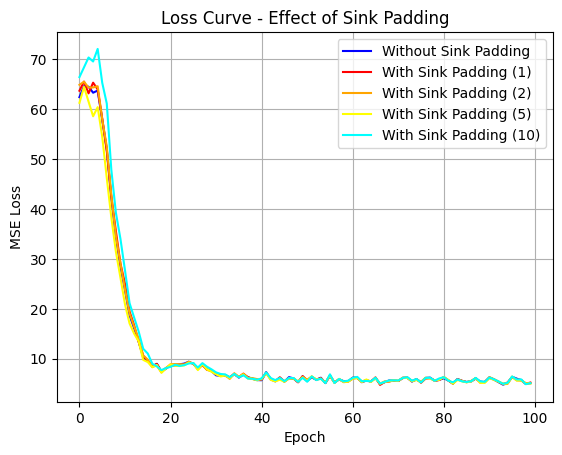

In [ ]:
plt.plot(experiment.loss_history, label='Without Sink Padding', color='blue')
plt.plot(experiment_with_sink_padding_1.loss_history, label='With Sink Padding (1)', color='red')
plt.plot(experiment_with_sink_padding_2.loss_history, label='With Sink Padding (2)', color='orange')
plt.plot(experiment_with_sink_padding_5.loss_history, label='With Sink Padding (5)', color='yellow')
plt.plot(experiment_with_sink_padding_10.loss_history, label='With Sink Padding (10)', color='cyan')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss Curve - Effect of Sink Padding')
plt.grid()
plt.legend()
plt.show()

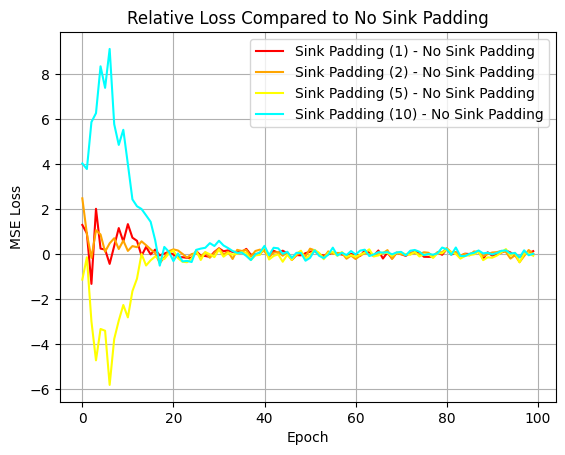

In [ ]:
plt.plot(list(map(sub, experiment_with_sink_padding_1.loss_history, experiment.loss_history)), label='Sink Padding (1) - No Sink Padding', color='red')
plt.plot(list(map(sub, experiment_with_sink_padding_2.loss_history, experiment.loss_history)), label='Sink Padding (2) - No Sink Padding', color='orange')
plt.plot(list(map(sub, experiment_with_sink_padding_5.loss_history, experiment.loss_history)), label='Sink Padding (5) - No Sink Padding', color='yellow')
plt.plot(list(map(sub, experiment_with_sink_padding_10.loss_history, experiment.loss_history)), label='Sink Padding (10) - No Sink Padding', color='cyan')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Relative Loss Compared to No Sink Padding')
plt.grid()
plt.legend()
plt.show()

#### Residual Gate 对比实验

##### 初始参数

In [271]:
init_parameters, train_parameters = default_setup()
train_parameters['epochs'] = 50

##### 各个实验

In [321]:
init_parameters['experiment_name'] = 'exp_without_residual_gate'
experiment_no_residual_gate = LoopedTransformerExperiment(**init_parameters)
experiment_no_residual_gate.train(**train_parameters)

exp_without_residual_gate initialized in 0.04 seconds. Using device: mps
Epoch 5/50, Loss: 20.7130, current_blocks: 19
Epoch 10/50, Loss: 18.5715, current_blocks: 20
Epoch 15/50, Loss: 21.2195, current_blocks: 20
Epoch 20/50, Loss: 21.0295, current_blocks: 20
Epoch 25/50, Loss: 19.8382, current_blocks: 20
Epoch 30/50, Loss: 19.0533, current_blocks: 20
Epoch 35/50, Loss: 20.3499, current_blocks: 20
Epoch 40/50, Loss: 18.0439, current_blocks: 20
Epoch 45/50, Loss: 20.3634, current_blocks: 20
Epoch 50/50, Loss: 20.1082, current_blocks: 20
Training completed in 18.90 seconds.


In [336]:
init_parameters['experiment_name'] = 'exp_with_residual_gate_(1, 0.5)'
init_parameters['residual_gate'] = (1, 0.5)
init_parameters['residual_gate_type'] = 'learnable_scalar'
experiment_with_residual_gate_1_05 = LoopedTransformerExperiment(**init_parameters)
experiment_with_residual_gate_1_05.train(**train_parameters)
print(f"Learned residual gate values (1, 0.5) experiment: {experiment_with_residual_gate_1_05.residual_gate_values}")

exp_with_residual_gate_(1, 0.5) initialized in 0.02 seconds. Using device: mps
Epoch 5/50, Loss: 29.2088, current_blocks: 19
Epoch 10/50, Loss: 20.1585, current_blocks: 20
Epoch 15/50, Loss: 22.8048, current_blocks: 20
Epoch 20/50, Loss: 22.2609, current_blocks: 20
Epoch 25/50, Loss: 20.5698, current_blocks: 20
Epoch 30/50, Loss: 19.4042, current_blocks: 20
Epoch 35/50, Loss: 20.9330, current_blocks: 20
Epoch 40/50, Loss: 18.3396, current_blocks: 20
Epoch 45/50, Loss: 20.6414, current_blocks: 20
Epoch 50/50, Loss: 20.4650, current_blocks: 20
Training completed in 18.99 seconds.
Learned residual gate values (1, 0.5) experiment: [0.9978354  0.49871778]


In [340]:
init_parameters['experiment_name'] = 'exp_with_residual_gate_(1, 0.5)'
init_parameters['residual_gate'] = (1, 0.5)
init_parameters['residual_gate_type'] = 'learnable_vector'
experiment_with_residual_gate_1_05_vector = LoopedTransformerExperiment(**init_parameters)
experiment_with_residual_gate_1_05_vector.train(**train_parameters)
print(f"Learned residual gate values (1, 0.5) experiment: mean={experiment_with_residual_gate_1_05_vector.residual_gate_values.mean(axis=0)}, std={experiment_with_residual_gate_1_05_vector.residual_gate_values.std(axis=0)}")

exp_with_residual_gate_(1, 0.5) initialized in 0.02 seconds. Using device: mps
Epoch 5/50, Loss: 29.1400, current_blocks: 19
Epoch 10/50, Loss: 20.1746, current_blocks: 20
Epoch 15/50, Loss: 22.8072, current_blocks: 20
Epoch 20/50, Loss: 22.2589, current_blocks: 20
Epoch 25/50, Loss: 20.5867, current_blocks: 20
Epoch 30/50, Loss: 19.4123, current_blocks: 20
Epoch 35/50, Loss: 20.9413, current_blocks: 20
Epoch 40/50, Loss: 18.3475, current_blocks: 20
Epoch 45/50, Loss: 20.6340, current_blocks: 20
Epoch 50/50, Loss: 20.4660, current_blocks: 20
Training completed in 20.17 seconds.
Learned residual gate values (1, 0.5) experiment: mean=[0.9993703  0.49956098], std=[0.00080971 0.00087863]


In [ ]:
init_parameters['experiment_name'] = 'exp_with_residual_gate_(1, 0)'
init_parameters['residual_gate'] = (1, 0)
init_parameters['residual_gate_type'] = 'learnable_scalar'
experiment_with_residual_gate_1_0 = LoopedTransformerExperiment(**init_parameters)
experiment_with_residual_gate_1_0.train(**train_parameters)
print(f"Learned residual gate values (1, 0) experiment: {experiment_with_residual_gate_1_0.residual_gate_values}")

exp_with_residual_gate_(1, 0) initialized in 0.06 seconds. Using device: mps
Epoch 5/50, Loss: 22.9985, current_blocks: 19
Epoch 10/50, Loss: 19.7026, current_blocks: 20
Epoch 15/50, Loss: 21.7824, current_blocks: 20
Epoch 20/50, Loss: 21.2914, current_blocks: 20
Epoch 25/50, Loss: 20.0851, current_blocks: 20
Epoch 30/50, Loss: 19.0451, current_blocks: 20
Epoch 35/50, Loss: 20.6282, current_blocks: 20
Epoch 40/50, Loss: 18.0635, current_blocks: 20
Epoch 45/50, Loss: 20.5348, current_blocks: 20
Epoch 50/50, Loss: 20.2935, current_blocks: 20
Training completed in 17.39 seconds.
Learned residual gate values (1, 0) experiment: [9.9716604e-01 8.8778639e-04]


In [342]:
init_parameters['experiment_name'] = 'exp_with_residual_gate_(1, 0)_vector'
init_parameters['residual_gate'] = (1, 0)
init_parameters['residual_gate_type'] = 'learnable_vector'
experiment_with_residual_gate_1_0_vector = LoopedTransformerExperiment(**init_parameters)
experiment_with_residual_gate_1_0_vector.train(**train_parameters)
print(f"Learned residual gate values (1, 0) experiment: mean={experiment_with_residual_gate_1_0_vector.residual_gate_values.mean(axis=0)}, std={experiment_with_residual_gate_1_0_vector.residual_gate_values.std(axis=0)}")

exp_with_residual_gate_(1, 0)_vector initialized in 0.05 seconds. Using device: mps
Epoch 5/50, Loss: 23.0180, current_blocks: 19
Epoch 10/50, Loss: 19.7157, current_blocks: 20
Epoch 15/50, Loss: 21.7938, current_blocks: 20
Epoch 20/50, Loss: 21.3009, current_blocks: 20
Epoch 25/50, Loss: 20.0920, current_blocks: 20
Epoch 30/50, Loss: 19.0482, current_blocks: 20
Epoch 35/50, Loss: 20.6345, current_blocks: 20
Epoch 40/50, Loss: 18.0703, current_blocks: 20
Epoch 45/50, Loss: 20.5377, current_blocks: 20
Epoch 50/50, Loss: 20.2944, current_blocks: 20
Training completed in 20.29 seconds.
Learned residual gate values (1, 0) experiment: mean=[9.9969363e-01 1.7938159e-04], std=[0.00050077 0.00050514]


In [372]:
init_parameters['experiment_name'] = 'exp_with_residual_gate_random_learnable_scalar'
init_parameters['residual_gate'] = 'random'
init_parameters['residual_gate_type'] = 'learnable_scalar'
init_parameters['residual_random'] = (0.9, 0.1)
experiment_with_residual_gate_learnable_scalar = LoopedTransformerExperiment(**init_parameters)
experiment_with_residual_gate_learnable_scalar.train(**train_parameters)
print(f"Learnable Scalar Residual Gate Values: {experiment_with_residual_gate_learnable_scalar.residual_gate_values}")

exp_with_residual_gate_random_learnable_scalar initialized in 0.07 seconds. Using device: mps
Epoch 5/50, Loss: 21.0580, current_blocks: 19
Epoch 10/50, Loss: 18.7716, current_blocks: 20
Epoch 15/50, Loss: 21.3869, current_blocks: 20
Epoch 20/50, Loss: 21.1843, current_blocks: 20
Epoch 25/50, Loss: 19.8457, current_blocks: 20
Epoch 30/50, Loss: 19.0577, current_blocks: 20
Epoch 35/50, Loss: 20.3878, current_blocks: 20
Epoch 40/50, Loss: 18.0605, current_blocks: 20
Epoch 45/50, Loss: 20.3509, current_blocks: 20
Epoch 50/50, Loss: 20.0638, current_blocks: 20
Training completed in 27.30 seconds.
Learnable Scalar Residual Gate Values: [0.6452778  0.87516636]


In [373]:
init_parameters['experiment_name'] = 'exp_with_residual_gate_learnable_vector'
init_parameters['residual_gate'] = 'random'
init_parameters['residual_gate_type'] = 'learnable_vector'
init_parameters['residual_random'] = (0.9, 0.1)
experiment_with_residual_gate_learnable_vector = LoopedTransformerExperiment(**init_parameters)
experiment_with_residual_gate_learnable_vector.train(**train_parameters)
print(f"Learnable Vector Residual Gate Values: mean={experiment_with_residual_gate_learnable_vector.residual_gate_values.mean(axis=0)}, std={experiment_with_residual_gate_learnable_vector.residual_gate_values.std(axis=0)}")

exp_with_residual_gate_learnable_vector initialized in 0.01 seconds. Using device: mps
Epoch 5/50, Loss: 35.3433, current_blocks: 19
Epoch 10/50, Loss: 24.2386, current_blocks: 20
Epoch 15/50, Loss: 24.8021, current_blocks: 20
Epoch 20/50, Loss: 23.5092, current_blocks: 20
Epoch 25/50, Loss: 21.6698, current_blocks: 20
Epoch 30/50, Loss: 20.2519, current_blocks: 20
Epoch 35/50, Loss: 21.4653, current_blocks: 20
Epoch 40/50, Loss: 18.7852, current_blocks: 20
Epoch 45/50, Loss: 20.8517, current_blocks: 20
Epoch 50/50, Loss: 20.8915, current_blocks: 20
Training completed in 17.84 seconds.
Learnable Vector Residual Gate Values: mean=[0.90723443 0.8975898 ], std=[0.0963758  0.09790894]


##### 画图

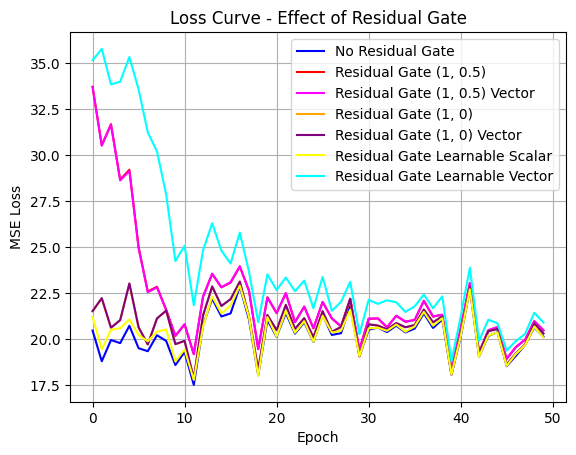

In [374]:
plt.plot(experiment_no_residual_gate.loss_history, label='No Residual Gate', color='blue')
plt.plot(experiment_with_residual_gate_1_05.loss_history, label='Residual Gate (1, 0.5)', color='red')
plt.plot(experiment_with_residual_gate_1_05_vector.loss_history, label='Residual Gate (1, 0.5) Vector', color='magenta')
plt.plot(experiment_with_residual_gate_1_0.loss_history, label='Residual Gate (1, 0)', color='orange')
plt.plot(experiment_with_residual_gate_1_0_vector.loss_history, label='Residual Gate (1, 0) Vector', color='purple')
plt.plot(experiment_with_residual_gate_learnable_scalar.loss_history, label='Residual Gate Learnable Scalar', color='yellow')
plt.plot(experiment_with_residual_gate_learnable_vector.loss_history, label='Residual Gate Learnable Vector', color='cyan')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss Curve - Effect of Residual Gate')
plt.grid()
plt.legend()
plt.show()

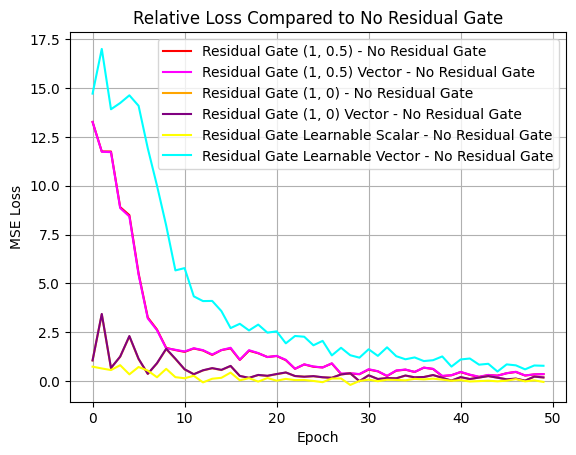

In [377]:
plt.plot(list(map(sub, experiment_with_residual_gate_1_05.loss_history, experiment_no_residual_gate.loss_history)), label='Residual Gate (1, 0.5) - No Residual Gate', color='red')
plt.plot(list(map(sub, experiment_with_residual_gate_1_05_vector.loss_history, experiment_no_residual_gate.loss_history)), label='Residual Gate (1, 0.5) Vector - No Residual Gate', color='magenta')
plt.plot(list(map(sub, experiment_with_residual_gate_1_0.loss_history, experiment_no_residual_gate.loss_history)), label='Residual Gate (1, 0) - No Residual Gate', color='orange')
plt.plot(list(map(sub, experiment_with_residual_gate_1_0_vector.loss_history, experiment_no_residual_gate.loss_history)), label='Residual Gate (1, 0) Vector - No Residual Gate', color='purple')
plt.plot(list(map(sub, experiment_with_residual_gate_learnable_scalar.loss_history, experiment_no_residual_gate.loss_history)), label='Residual Gate Learnable Scalar - No Residual Gate', color='yellow')
plt.plot(list(map(sub, experiment_with_residual_gate_learnable_vector.loss_history, experiment_no_residual_gate.loss_history)), label='Residual Gate Learnable Vector - No Residual Gate', color='cyan')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Relative Loss Compared to No Residual Gate')
plt.grid()
plt.legend()
plt.show()